In [ ]:
# -------------------------------------------
# 
# generate and save climate input files 
# 
# -------------------------------------------

# Need the following 1d arrays --------------
# 
# [ time ]: decimal year 
# [ temperature ]: degrees C
# [ soil moisture ]: mm / m
# 
import os 

import fsspec
import icechunk 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.style as mplstyle
import numpy as np
import pandas as pd
import s3fs
import xarray as xr

from ew_workflows import clim_process_helperfxns as cph

# *****************************************************************
# [ gcam site group for save name ]
deg_resolution = 1 
save_subdir = f'one-cell-per-region_{deg_resolution}deg'
# *****************************************************************

# --- read in site data
datpath = 's3://carbonplan-carbon-removal/ew-workflows-data/gcam/apprate_calculated/one-cell-per-region'
fn = f'annual_rockflx_densest-ag-region_{deg_resolution}deg.pkl'
dfx = pd.read_pickle(os.path.join(datpath, fn))
# get unique coords
df = dfx.drop_duplicates(subset=["lat", "lon"])

In [47]:
# --- create site names
df = df.sort_values(["region", "lat", "lon"]).copy()
# create tuple column
df["latlon"] = list(zip(df["lat"], df["lon"]))
# assign per-region integer ID
df["X"] = (
    df.groupby("region")["latlon"]
      .transform(lambda s: pd.factorize(s)[0] + 1)
)
# final unique identifier
df["region_uid"] = df["region"] + "_" + df["X"].astype(str)
# drop helper columns
df = df.drop(columns=["latlon", "X"])

# --- create site dictionary
df_unique = df.drop_duplicates("region_uid")
# convert lon to 0-360
df_unique['lon360'] = df_unique['lon'] % 360
site_dict = {
    row["region_uid"]: {
        "xlat": row["lat"],
        "xlon": row["lon360"],
        "name": row["region_uid"],
    }
    for _, row in df_unique.iterrows()
}

In [19]:
# select layers for mean column -------------
# for more info on soil layers, see: https://codes.ecmwf.int/grib/param-db/39 
soilwater_layers = ["volumetric_soil_water_layer_1", "volumetric_soil_water_layer_2"]
soiltemperature_layers = ["soil_temperature_level_1", "soil_temperature_level_2"]
# select the 1d variables
runoff_vars = ["sub_surface_runoff"]

# select time resolutions to output ---------
default_res_name = "hourly"  # name for the native time resolution
default_resolution = False    # native time resolution
daily_mean = False            # average of each day 
daily_ltm = False            # climatological average of each day 
monthly_mean = False          # average of each month (length = 12 * nyears)
monthly_ltm = False           # climatological average of each month (length = 12)
annual_mean = False           # average of each year (length = nyears)
annual_ltm = True            # climatological annual average (length = 1)

# do we need to convert era5 units ----------
era5_unit_conversions_on = True

# how many times to repeat the selected years in the climate file 
ltm_repeat = True  # whether to repeat ltm data for duration of total time (multiplied by nyears_repeat)
nyears_repeat = 80   # repeat timeseries for all resolutions
                    # (TODO: There may be a problem with repetition where timesteps get repeated...
                    #        scepter runs with repetition were failing for indexing issues in the 
                    #        clim files, and I suspect this is the culprit... )
roundtime_to = 5    # number of decimal places to round decimal time (5 works for hourly)

# select start and end time + sites -----------
mintime = '2001-01-01'
maxtime = '2015-12-31'

# where to save the data -----------------------
# (note, we'll make a subdir that is `era5_mintime_maxtime`)
# savepath = "/home/tykukla/ew-workflows/era5/scepter-ready"
savepath = "s3://carbonplan-carbon-removal/ew-workflows-data/scepter/clim"
save_maindir = os.path.join(savepath, save_subdir)
subdir_rule = "combined"

# input file for var details -------------------
inputvar_details_fn = "/Users/tylerkukla/Documents/GitHub/ew-workflows/era5/process/scepter/inputvar_details.txt"

# whether to save climate figure ---------------
save_clim_fig = True


In [21]:
# --- read in data
era5_dir = "era5/preprocessed_icechunk"
era5_bucket = "carbonplan-carbon-removal"

storage = icechunk.s3_storage(bucket=era5_bucket, prefix=era5_dir, from_env=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
rtds = xr.open_zarr(session.store, consolidated=False)
rtds

<xarray.Dataset> Size: 466GB
Dimensions:                        (time: 184104, latitude: 105, longitude: 241)
Coordinates:
  * latitude                       (latitude) float32 420B 50.0 49.75 ... 24.0
    level                          int64 8B ...
  * longitude                      (longitude) float32 964B 235.0 ... 295.0
  * time                           (time) datetime64[ns] 1MB 2000-01-01 ... 2...
Data variables: (12/25)
    10m_v_component_of_wind        (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    geopotential_at_surface        (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    10m_u_component_of_wind        (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    evaporation                    (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    2m_temperature                 (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    forecast_albedo                (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    ...                             ...
    v_component_of_wind            (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    total_precipitation            (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_1  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_2  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_4  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_3  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
Attributes:
    last_updated:           2025-09-22 01:57:27.339380+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-09-16

In [ ]:
site_dict['Brazil_1']

262.49999999999994

In [51]:
tlat = site_dict['Brazil_1']['xlat']
tlon = site_dict['Brazil_1']['xlon']
rtds['sub_surface_runoff'].sel(latitude = tlat, longitude = tlon, method='nearest')

<xarray.DataArray 'sub_surface_runoff' (time: 184104)> Size: 736kB
dask.array<getitem, shape=(184104,), dtype=float32, chunksize=(184104,), chunktype=numpy.ndarray>
Coordinates:
    latitude   float32 4B 24.0
    level      int64 8B ...
    longitude  float32 4B 295.0
  * time       (time) datetime64[ns] 1MB 2000-01-01 ... 2020-12-31T23:00:00
Attributes:
    long_name:   Sub-surface runoff
    short_name:  ssro
    units:       m

## [1] Create climate var dataset 

In [22]:
# --- create climate var dataset 
dsvar, nyears_data = cph.create_climvars_ds(
    rtds,
    site_dict,
    mintime, 
    maxtime,
    soilwater_layers,
    soiltemperature_layers,
    runoff_vars,
    roundtime_to,
    era5_unit_conversions_on,
)

/Users/tylerkukla/Documents/GitHub/ew-workflows/src/ew_workflows/clim_process_helperfxns.py:126: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  dsx = xr.concat(dslist, dim='site')


## [2] Create a dataset for each time resolution

In [23]:
ds_dict = cph.create_dsdict_across_timeResolutions(
    dsvar,
    default_res_name,
    default_resolution,
    daily_mean, 
    daily_ltm,
    monthly_mean,
    monthly_ltm,
    annual_mean,
    annual_ltm,
    roundtime_to,
    start_at_zero=True,
)

## [3] Save all sites and time resolutions as SCEPTER input files

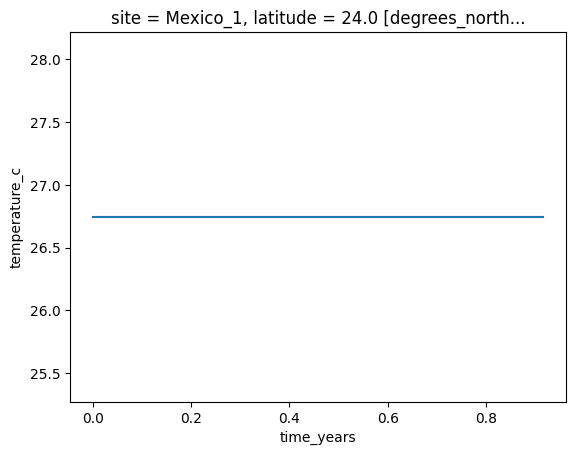

In [30]:
ds_dict['yearly_ltm'].isel(site=20)['temperature_c'].plot()

In [31]:
cph.save_all_case_climfiles_as_txt(
    ds_dict,
    nyears_repeat, # number of times to repeat data. # nyears_data,
    save_maindir,
    inputvar_details_fn,
    save_clim_fig,
    subdir_rule,
    ltm_repeat,
)

Now saving: Africa_Eastern_1 -- yearly_ltm
Now saving: Africa_Northern_1 -- yearly_ltm
Now saving: Africa_Southern_1 -- yearly_ltm
Now saving: Africa_Western_1 -- yearly_ltm
Now saving: Argentina_1 -- yearly_ltm
Now saving: Australia_NZ_1 -- yearly_ltm
Now saving: Brazil_1 -- yearly_ltm
Now saving: Canada_1 -- yearly_ltm
Now saving: Central America and Caribbean_1 -- yearly_ltm
Now saving: Central Asia_1 -- yearly_ltm
Now saving: China_1 -- yearly_ltm
Now saving: Colombia_1 -- yearly_ltm
Now saving: EU-12_1 -- yearly_ltm
Now saving: EU-15_1 -- yearly_ltm
Now saving: Europe_Eastern_1 -- yearly_ltm
Now saving: Europe_Non_EU_1 -- yearly_ltm
Now saving: European Free Trade Association_1 -- yearly_ltm
Now saving: India_1 -- yearly_ltm
Now saving: Indonesia_1 -- yearly_ltm
Now saving: Japan_1 -- yearly_ltm
Now saving: Mexico_1 -- yearly_ltm
Now saving: Middle East_1 -- yearly_ltm
Now saving: Pakistan_1 -- yearly_ltm
Now saving: Russia_1 -- yearly_ltm
Now saving: South Africa_1 -- yearly_ltm


In [ ]:
# ----